In [20]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset

df = pd.read_csv("tcc_ceds_music.csv", encoding = "ISO-8859-1")

# Display first 5 rows
df.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pÃ©rez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


In [3]:
# Basic information about dataset

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)



Shape of dataset: (28372, 31)

Column names:
 Index(['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre',
       'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time',
       'shake the audience', 'family/gospel', 'romantic', 'communication',
       'obscene', 'music', 'movement/places', 'light/visual perceptions',
       'family/spiritual', 'like/girls', 'sadness', 'feelings', 'danceability',
       'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy',
       'topic', 'age'],
      dtype='object')


In [4]:
# Info about data types and missing values
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28372 non-null  int64  
 1   artist_name               28372 non-null  object 
 2   track_name                28372 non-null  object 
 3   release_date              28372 non-null  int64  
 4   genre                     28372 non-null  object 
 5   lyrics                    28372 non-null  object 
 6   len                       28372 non-null  int64  
 7   dating                    28372 non-null  float64
 8   violence                  28372 non-null  float64
 9   world/life                28372 non-null  float64
 10  night/time                28372 non-null  float64
 11  shake the audience        28372 non-null  float64
 12  family/gospel             28372 non-null  float64
 13  romantic                  28372 non-null  float64
 14  commun

In [5]:
# Statistical summary
df.describe()

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
count,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,...,28372.000000,28372.000000,28372.000000,28372.000000,28372.000000,2.837200e+04,28372.000000,28372.000000,28372.000000,28372.000000
mean,42946.323558,1990.236888,73.028444,0.021112,0.118396,0.120973,0.057387,0.017422,0.017045,0.048681,...,0.028057,0.129389,0.030996,0.533348,0.665249,3.392347e-01,0.080049,0.532864,0.569875,0.425187
std,24749.325492,18.487463,41.829831,0.052370,0.178684,0.172200,0.111923,0.040670,0.041966,0.106095,...,0.058473,0.181143,0.071652,0.173218,0.108434,3.267143e-01,0.211245,0.250972,0.244385,0.264107
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,...,0.000284,0.000284,0.000289,0.005415,0.000000,2.811248e-07,0.000000,0.000000,0.000000,0.014286
25%,20391.250000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,...,0.000975,0.001144,0.000993,0.412975,0.595364,3.423598e-02,0.000000,0.329143,0.380361,0.185714
50%,45405.500000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,...,0.001595,0.005263,0.001754,0.538612,0.679050,2.259028e-01,0.000085,0.539365,0.580567,0.414286
75%,64090.500000,2007.000000,93.000000,0.004049,0.192608,0.197793,0.065842,0.010002,0.004785,0.042301,...,0.026622,0.235113,0.032622,0.656666,0.749026,6.325298e-01,0.009335,0.738252,0.772766,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,...,0.594459,0.981424,0.958810,0.993502,1.000000,1.000000e+00,0.996964,1.000000,1.000000,1.000000


In [6]:
# Check missing values

missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
like/girls                  0
sadness                     0
feelings                    0
danceability                0
loudness                    0
acousticness                0
instrumentalness            0
valence                     0
energy                      0
topic                       0
age                         0
dtype: int64


In [7]:
# Drop rows with missing values (simple beginner method)

df = df.dropna()

print("After removing missing values:", df.shape)

After removing missing values: (28372, 31)


In [21]:
# Drop unnecessary columns

columns_to_drop = ['lyrics','Unnamed: 0']  # lyrics not used for numerical analysis

df = df.drop(columns=columns_to_drop, errors='ignore')

df.head()

,artist_name,track_name,release_date,genre,len,dating,violence,world/life,night/time,shake the audience,...,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age,decade,mood_score
0,mukesh,mohabbat bhi jhoothi,1950,pop,95,0.000598,0.063746,0.000598,0.000598,0.000598,...,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0,1950,-0.040851
1,frankie laine,i believe,1950,pop,51,0.035537,0.096777,0.443435,0.001284,0.001284,...,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0,1950,0.323737
2,johnnie ray,cry,1950,pop,24,0.002770,0.002770,0.002770,0.002770,0.002770,...,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0,1950,0.349044
3,pÃ©rez prado,patricia,1950,pop,54,0.048249,0.001548,0.001548,0.001548,0.021500,...,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0,1950,0.549461
4,giorgos papadopoulos,apopse eida oneiro,1950,pop,48,0.001350,0.001350,0.417772,0.001350,0.001350,...,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0,1950,0.528273


In [22]:
# Create decade column from year

df['decade'] = (df['release_date'] // 10) * 10
# To group different years in decades
df[['release_date', 'decade']].iloc[14:23]

,release_date,decade
14,1951,1950
15,1951,1950
16,1951,1950
17,1951,1950
18,1952,1950
19,1952,1950
20,1952,1950
21,1952,1950
22,1952,1950


In [23]:
# Create a new feature: mood score
df['valence'] = pd.to_numeric(df['valence'], errors='coerce')
df['mood_score'] = df['valence'] - df['sadness']

df[['valence', 'sadness', 'mood_score']].head()

,valence,sadness,mood_score
0,0.339448,0.380299,-0.040851
1,0.325021,0.001284,0.323737
2,0.351814,0.002770,0.349044
3,0.775350,0.225889,0.549461
4,0.597073,0.068800,0.528273


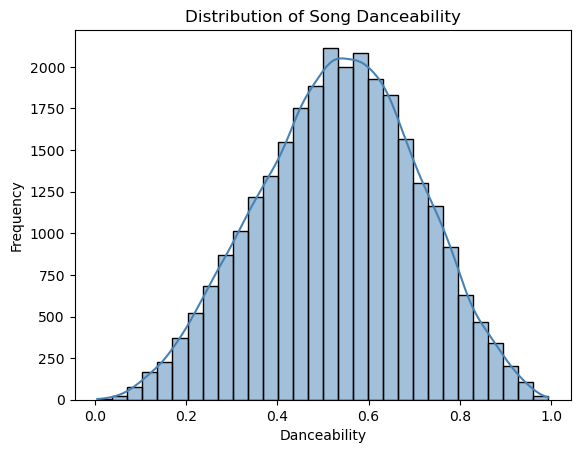

In [11]:
# Distribution of danceability

plt.figure()
sns.histplot(data=df, x='danceability', bins=30, color='steelblue', kde=True)
plt.title("Distribution of Song Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.show()

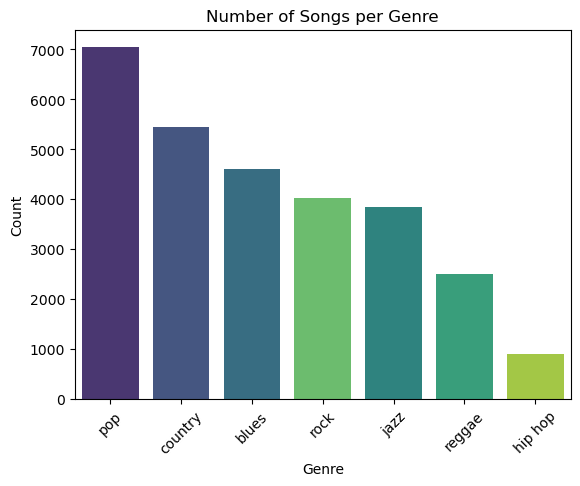

In [12]:
# Count of songs per genre


plt.figure()
sns.countplot(data=df, x='genre' , order=df['genre'].value_counts().index, hue='genre', palette='viridis')
plt.title("Number of Songs per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

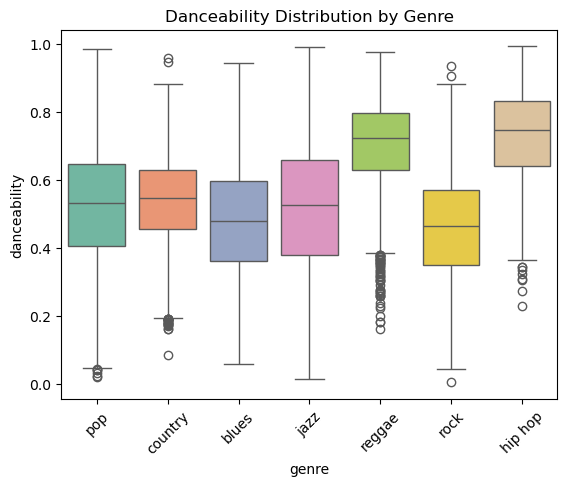

In [13]:
plt.figure()
sns.boxplot(x='genre', y='danceability', data=df , hue='genre', palette='Set2')
plt.title("Danceability Distribution by Genre")
plt.xticks(rotation=45)
plt.show()

          energy  danceability   valence
decade                                  
1950    0.312325      0.470689  0.499630
1960    0.414836      0.485890  0.564931
1970    0.524892      0.510577  0.579475
1980    0.583139      0.538657  0.569479
1990    0.586370      0.539857  0.521222
2000    0.655217      0.544614  0.507281
2010    0.665913      0.575267  0.489945


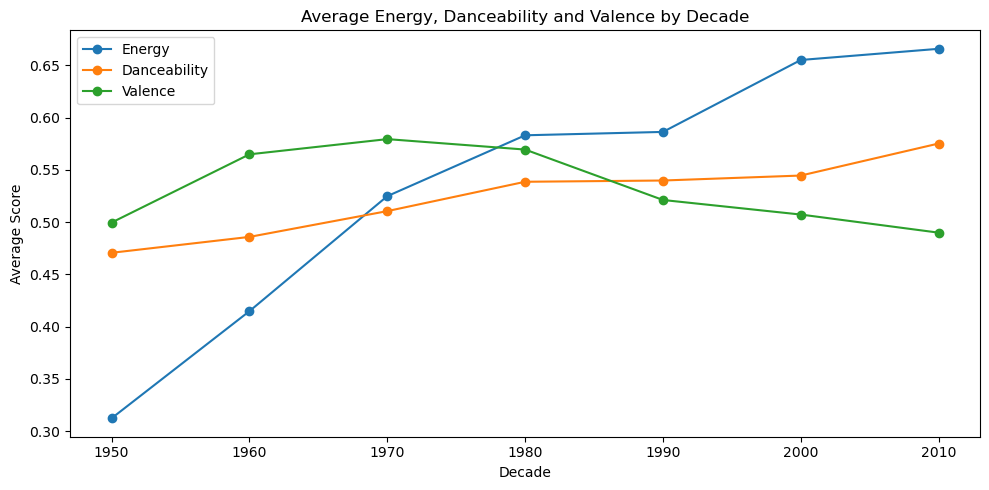

In [31]:
# Average danceability,energy and valence over decades

decade_trends=df.groupby('decade')[['energy' , 'danceability' , 'valence']].mean()
print(decade_trends)
plt.figure(figsize=(10,5))
plt.plot(decade_trends.index, decade_trends['energy'], marker='o' , label='Energy')
plt.plot(decade_trends.index, decade_trends['danceability'], marker='o' , label='Danceability')
plt.plot(decade_trends.index, decade_trends['valence'], marker='o', label='Valence')
plt.title('Average Energy, Danceability and Valence by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.show()

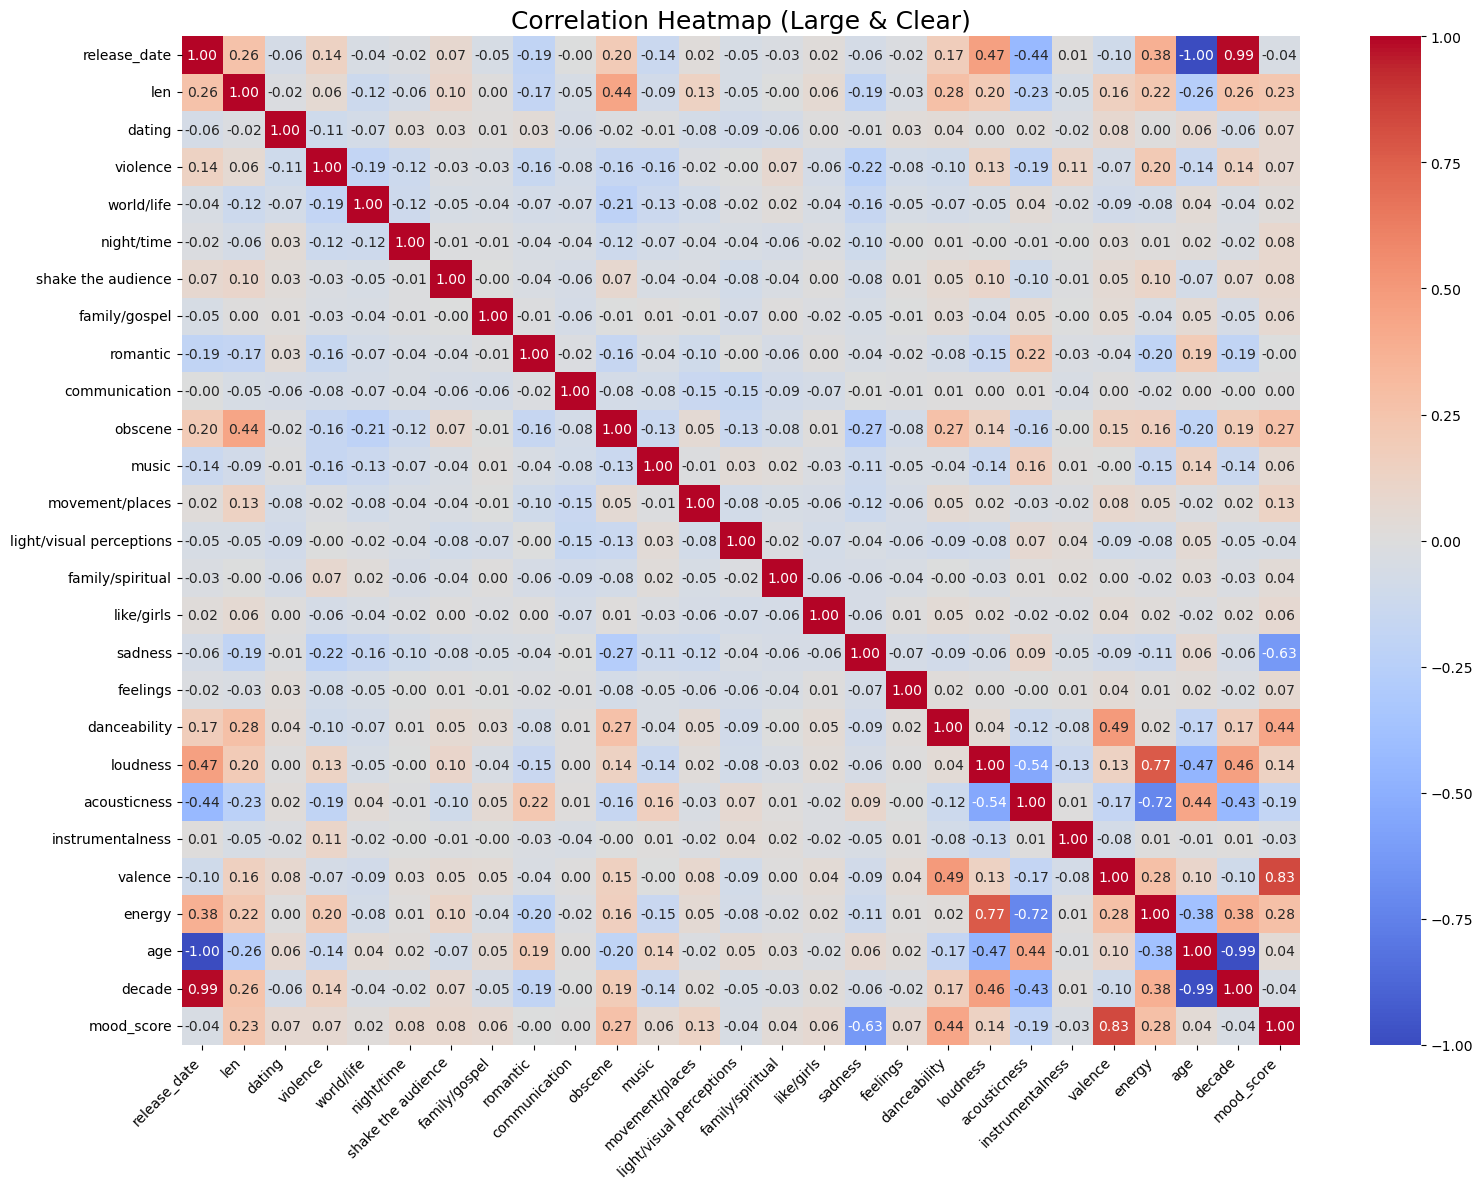

In [15]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
correlation = numeric_df.corr()

# Make figure LARGE
plt.figure(figsize=(16,12))

# Draw heatmap
sns.heatmap(
    correlation,
    annot=True,          # show values
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # color style
    square=False,
    cbar=True
)

# Rotate labels for clarity
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Heatmap (Large & Clear)", fontsize=18)

plt.tight_layout()   # VERY IMPORTANT (fixes overlap)

plt.show()

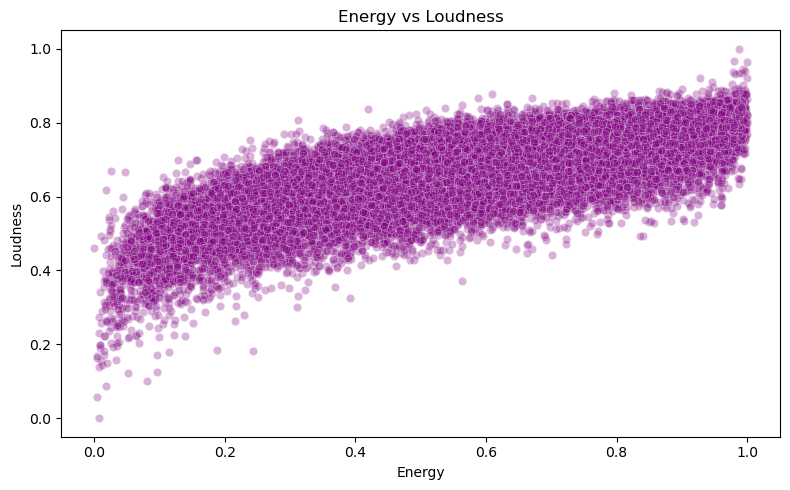

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='energy', y='loudness', alpha=0.3, color='purple')
plt.title('Energy vs Loudness')
plt.xlabel('Energy')
plt.ylabel('Loudness')
plt.tight_layout()
plt.show()

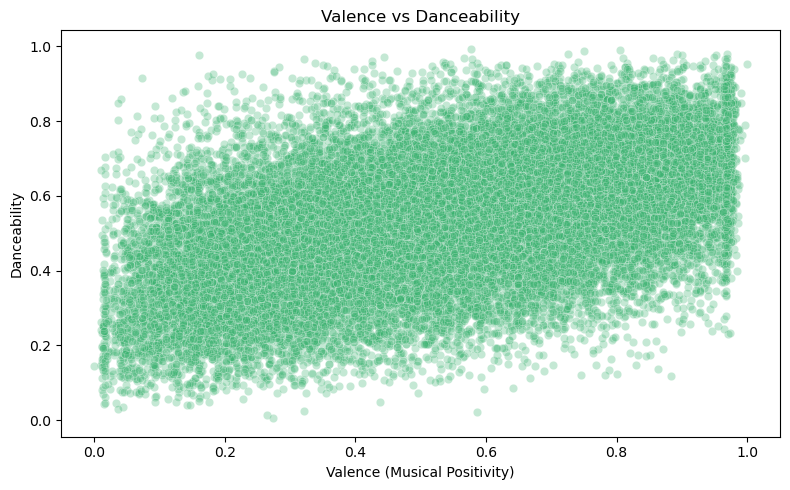

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='valence', y='danceability', alpha=0.3, color='mediumseagreen')
plt.title('Valence vs Danceability')
plt.xlabel('Valence (Musical Positivity)')
plt.ylabel('Danceability')
plt.tight_layout()
plt.show()

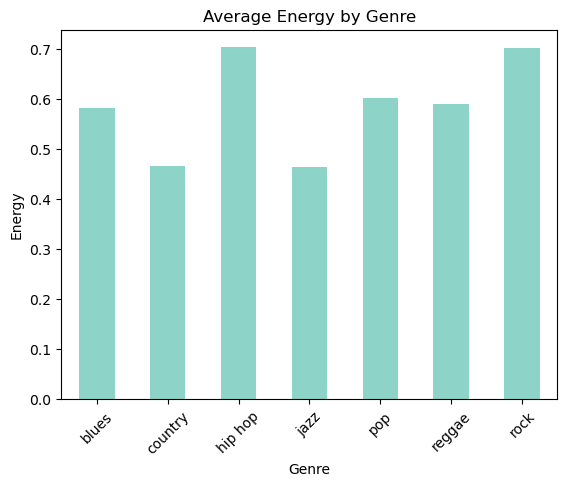

In [18]:
# Average energy per genre
df['energy'] = pd.to_numeric(df['energy'], errors='coerce')
energy_by_genre = df.groupby('genre')['energy'].mean()

plt.figure()
energy_by_genre.plot(kind='bar',colormap='Set3')
plt.title("Average Energy by Genre")
plt.xlabel("Genre")
plt.ylabel("Energy")
plt.xticks(rotation=45)
plt.show()

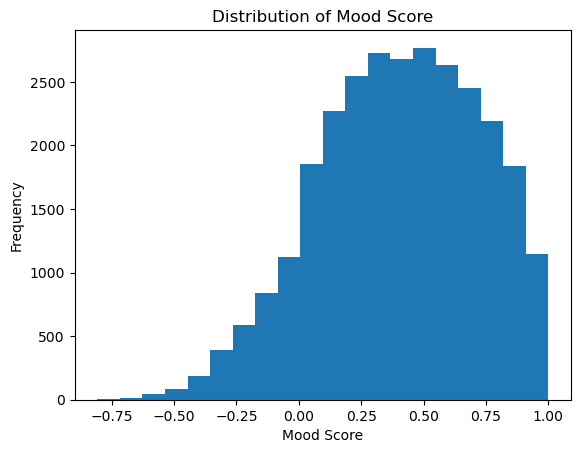

In [19]:
# Mood score analysis

plt.figure()
plt.hist(df['mood_score'], bins=20)
plt.title("Distribution of Mood Score")
plt.xlabel("Mood Score")
plt.ylabel("Frequency")
plt.show()